# Xenium HBC1 · V1002 exploratory niches

Official [10x Xenium FFPE Human Breast Cancer Replicate 1](https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_outs.zip), with supervised cell labels from the [10x Janesick companion](https://github.com/10XGenomics/janesick_nature_comms_2023_companion). The dataset is the current-study ST anchor. No bulk, survival, phenotype, simulation, or biological niche names are used. Restart the kernel, then Run All.

## 1. Imports and fixed exploratory settings

In [1]:
import sys
from pathlib import Path
ROOT=Path('/data1/xueshuailin/CCC_Phe_Niche')
SOURCE=Path('/home/xueshuailin/CCC_Phe/V1002/src')
if str(SOURCE) in sys.path: sys.path.remove(str(SOURCE))
sys.path.insert(0,str(SOURCE))
import numpy as np, pandas as pd, anndata as ad, matplotlib.pyplot as plt, torch
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown
from scipy.spatial import cKDTree
from phenoniche.v1001.neighborhoods import build_neighborhoods
from phenoniche.v1002.lr_atlas import load_lr_atlas, LRAtlas
from phenoniche.v1002.simulation_cells import _side_expression, aggregate_pairwise_ccc
from phenoniche.v1002.final_model import fit_balanced
N_NEIGHBORS=30
SIGMA_UM=20.0  # fixed Gaussian distance scale in official micron coordinates
K_NICHE=8
SEED=40700
DEVICE='cuda:0' if torch.cuda.is_available() else 'cpu'


## 2. Processed cells and official labels

In [2]:
path=ROOT/'data/Xenium_HBC1/processed/HBC1_Xenium_processed.h5ad'
adata=ad.read_h5ad(path)
assert adata.uns['dataset']=='Xenium_FFPE_Human_Breast_Cancer_Rep1'
assert adata.obs.cell_id.is_unique and adata.obs_names.equals(pd.Index(adata.obs.cell_id))
assert np.isfinite(adata.obsm['spatial']).all()
coordinates=adata.obsm['spatial'].astype(np.float32)
label_categories=sorted(adata.obs.cell_type_coarse.unique())
cell_type=pd.Categorical(adata.obs.cell_type_coarse,categories=label_categories).codes.astype(np.int16)
assert (cell_type>=0).all()
T=len(label_categories); N=adata.n_obs
ranges=f"x {coordinates[:,0].min():.0f}–{coordinates[:,0].max():.0f} µm; y {coordinates[:,1].min():.0f}–{coordinates[:,1].max():.0f} µm"
display(pd.DataFrame([{'Cells':N,'Genes':adata.n_vars,'Cell types':T,'Coordinate range':ranges}]))
display(adata.obs.cell_type_coarse.value_counts().rename_axis('Official cell type').to_frame('n_cells'))


,Cells,Genes,Cell types,Coordinate range
0,166363,313,20,x 2–7523 µm; y 3–5474 µm


,n_cells
Official cell type,
Stromal,41422
Invasive_Tumor,34374
DCIS_1,12923
DCIS_2,11683
Macrophages_1,11174
Endothelial,8931
CD4+_T_Cells,8453
Unlabeled,7137
Myoepi_ACTA2+,7078


## 3. Official cell-type spatial map

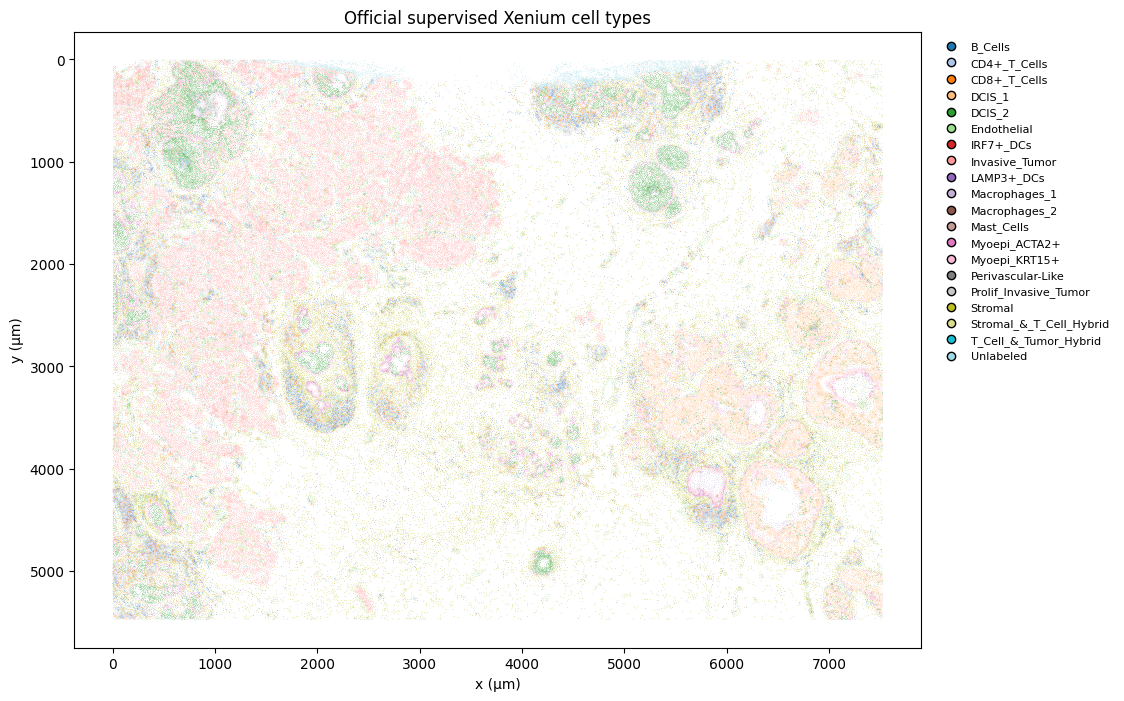

In [3]:
type_colors=plt.get_cmap('tab20',T)(np.arange(T))
fig,ax=plt.subplots(figsize=(11,8))
ax.scatter(coordinates[:,0],coordinates[:,1],c=type_colors[cell_type],s=.24,linewidths=0,rasterized=True)
ax.set(xlabel='x (µm)',ylabel='y (µm)',title='Official supervised Xenium cell types')
ax.set_aspect('equal'); ax.invert_yaxis()
handles=[plt.Line2D([0],[0],marker='o',color='none',markerfacecolor=type_colors[i],markersize=6,label=name) for i,name in enumerate(label_categories)]
ax.legend(handles=handles,bbox_to_anchor=(1.01,1),loc='upper left',frameon=False,fontsize=8)
plt.show()


## 4. Fixed V1002 neighborhoods and composition

In [4]:
neighborhoods=build_neighborhoods(coordinates,k=N_NEIGHBORS,sigma=SIGMA_UM)
members=neighborhoods.indices.reshape(N,N_NEIGHBORS)
anchor_weights=neighborhoods.weights.reshape(N,N_NEIGHBORS).astype(np.float32)
BATCH=256
C,_,opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,np.zeros((N,1),dtype=np.float32),np.zeros((N,1),dtype=np.float32),
    T,sigma=SIGMA_UM,members=members,anchor_weights=anchor_weights,
    batch_size=BATCH,device=DEVICE,compute_signal=False,
)
pair_support=(opportunity>0).sum(0)
assert np.allclose(C.sum(1),1,atol=1e-5)


## 5. Measurable LR atlas and outcome-blind CCC mask

In [5]:
atlas=load_lr_atlas(str(SOURCE.parent/'data/commuspace_human_lr_atlas.tsv'))
panel=set(adata.var_names.str.upper())
measurable=tuple(row for row in atlas.interactions if all(g in panel for g in row.ligand_components+row.receptor_components))
measurable_atlas=LRAtlas(measurable,{'n_raw_lr':len(atlas),'n_unique_lr':len(measurable)},atlas.source_path)
if not measurable: raise RuntimeError('No fully measurable LR interaction in the Xenium panel')
lr_genes=tuple(sorted({g for row in measurable for g in row.ligand_components+row.receptor_components}))
expression=np.column_stack([adata[:,gene].X.toarray().ravel() for gene in lr_genes]).astype(np.float32)
ligand,receptor=_side_expression(expression,lr_genes,measurable_atlas)
coverage_l=np.stack([(ligand[cell_type==t]>0).mean(0) for t in range(T)])
coverage_r=np.stack([(receptor[cell_type==t]>0).mean(0) for t in range(T)])
coverage=((coverage_l[:,None,:]>=.10)&(coverage_r[None,:,:]>=.10)).reshape(T*T,-1)
supported=pair_support>=max(20,int(np.ceil(.01*N)))
feature_mask=(coverage&supported[:,None]).reshape(-1)
final_ccc=int(feature_mask.sum())
display(pd.DataFrame([{'Panel genes':adata.n_vars,'Atlas LR pairs':len(atlas),
                       'Fully measurable LR pairs':len(measurable),'Final directed CCC features':final_ccc}]))
if len(measurable)<100:
    display(Markdown('**WARNING:** Xenium 313-gene panel provides limited LR coverage; the following niche result is exploratory.'))
if final_ccc==0: raise RuntimeError('No directed CCC feature passed the fixed outcome-blind filter')


,Panel genes,Atlas LR pairs,Fully measurable LR pairs,Final directed CCC features
0,313,8408,40,3344


**WARNING:** Xenium 313-gene panel provides limited LR coverage; the following niche result is exploratory.

## 6. Chunked directed CCC from the same neighborhoods

In [6]:
I=np.empty((N,final_ccc),dtype=np.float32)
_,I,signal_opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,sigma=SIGMA_UM,
    members=members,anchor_weights=anchor_weights,feature_mask=feature_mask,
    batch_size=BATCH,device=DEVICE,communication_out=I,
)
assert np.allclose(opportunity,signal_opportunity,rtol=1e-5,atol=1e-6)
del signal_opportunity
assert I.shape==(N,final_ccc) and np.isfinite(I).all()


## 7. V1002 flat C+I factorization, K=8

In [7]:
fit=fit_balanced({'HC':C,'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
W=np.maximum(fit.W.numpy(),0)
W=W/np.maximum(W.sum(1,keepdims=True),1e-12)
niche=W.argmax(1)
assert W.shape==(N,K_NICHE)


## 8. Matched spatial maps

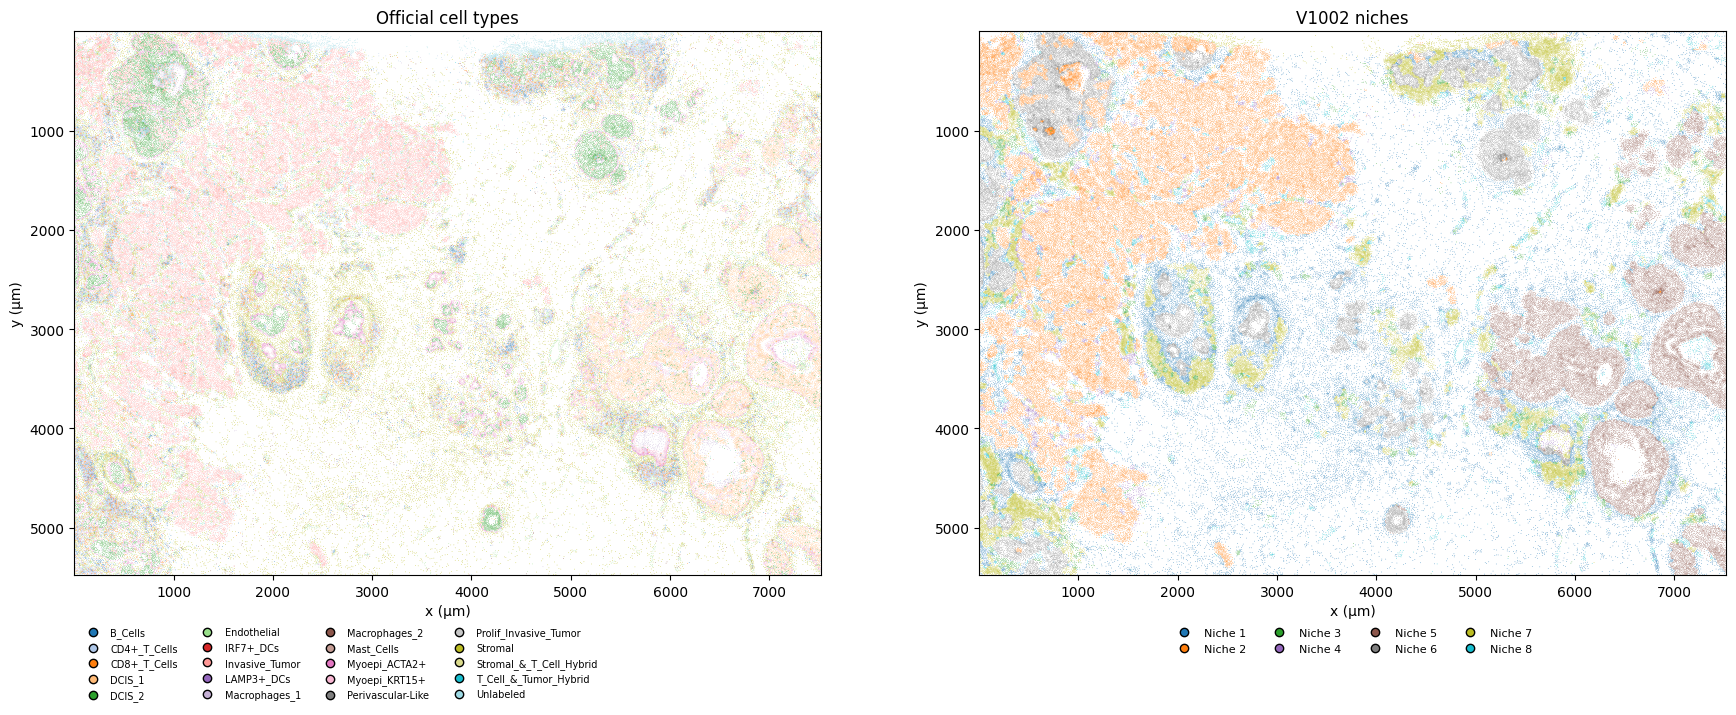

In [8]:
niche_colors=plt.get_cmap('tab10',K_NICHE)(np.arange(K_NICHE))
fig,axes=plt.subplots(1,2,figsize=(18,7),constrained_layout=True)
for ax,colors,title in [(axes[0],type_colors[cell_type],'Official cell types'),
                        (axes[1],niche_colors[niche],'V1002 niches')]:
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(xlabel='x (µm)',ylabel='y (µm)',title=title)
    ax.set_xlim(coordinates[:,0].min(),coordinates[:,0].max())
    ax.set_ylim(coordinates[:,1].max(),coordinates[:,1].min())
    ax.set_aspect('equal')
axes[0].legend(handles=handles,bbox_to_anchor=(.0,-.08),loc='upper left',ncol=4,frameon=False,fontsize=7)
niche_handles=[plt.Line2D([0],[0],marker='o',color='none',markerfacecolor=niche_colors[k],markersize=6,label=f'Niche {k+1}') for k in range(K_NICHE)]
axes[1].legend(handles=niche_handles,bbox_to_anchor=(.5,-.08),loc='upper center',ncol=4,frameon=False,fontsize=8)
plt.show()


## 9. Small composition summary

In [9]:
background=np.maximum(C.mean(0),1e-8)
rows=[]
for k in range(K_NICHE):
    selected=niche==k; count=int(selected.sum())
    enriched=[] if count==0 else [label_categories[j] for j in np.argsort(-(C[selected].mean(0)/background))[:3]]
    rows.append({'Niche':f'Niche {k+1}','n_cells':count,'fraction':count/N,'top 3 enriched cell types':', '.join(enriched)})
display(pd.DataFrame(rows).round({'fraction':3}))


,Niche,n_cells,fraction,top 3 enriched cell types
0,Niche 1,36942,0.222,"Stromal, Mast_Cells, Macrophages_2"
1,Niche 2,45518,0.274,"Prolif_Invasive_Tumor, Invasive_Tumor, T_Cell_..."
2,Niche 3,6328,0.038,"Macrophages_2, B_Cells, IRF7+_DCs"
3,Niche 4,3157,0.019,"T_Cell_&_Tumor_Hybrid, Macrophages_1, Prolif_I..."
4,Niche 5,21740,0.131,"DCIS_1, Myoepi_KRT15+, Myoepi_ACTA2+"
5,Niche 6,20314,0.122,"DCIS_2, Myoepi_ACTA2+, Myoepi_KRT15+"
6,Niche 7,25994,0.156,"LAMP3+_DCs, CD4+_T_Cells, IRF7+_DCs"
7,Niche 8,6370,0.038,"Perivascular-Like, Endothelial, Macrophages_2"


# 真实数据多视图贡献验证

本节不使用人工区域标签训练模型。组成视图、CCC 视图与已有 Full V1002 使用同一 K、随机种子及优化设置。单视图 niche 编号仅在训练后对齐到 Full，以便比较空间图；官方 cell type 只用于描述性诊断。这里检查组成和通讯各自解释的空间结构，以及 Full 是否在单视图之上区分局部生态状态。

## 固定参数的两个单视图消融

In [10]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import jensenshannon
from scipy import sparse
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from itertools import combinations
assert K_NICHE==8 and W.shape==(N,K_NICHE) and I.shape[0]==N
assert fit.W.shape[1]==K_NICHE
ablation={}
for method,blocks in [('Composition only',{'HC':C}),('CCC only',{'HI':I})]:
    result=fit_balanced(blocks,seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
    activity=np.maximum(result.W.numpy(),0)
    activity/=np.maximum(activity.sum(1,keepdims=True),1e-12)
    raw=activity.argmax(1)
    overlap=np.bincount(raw*K_NICHE+niche,minlength=K_NICHE*K_NICHE).reshape(K_NICHE,K_NICHE)
    source_ids,full_ids=linear_sum_assignment(-overlap)
    mapping=np.empty(K_NICHE,dtype=np.int64);mapping[source_ids]=full_ids
    ablation[method]={'raw':raw,'aligned':mapping[raw]}
composition_niche=ablation['Composition only']['aligned']
ccc_niche=ablation['CCC only']['aligned']


## 1×4 空间消融图

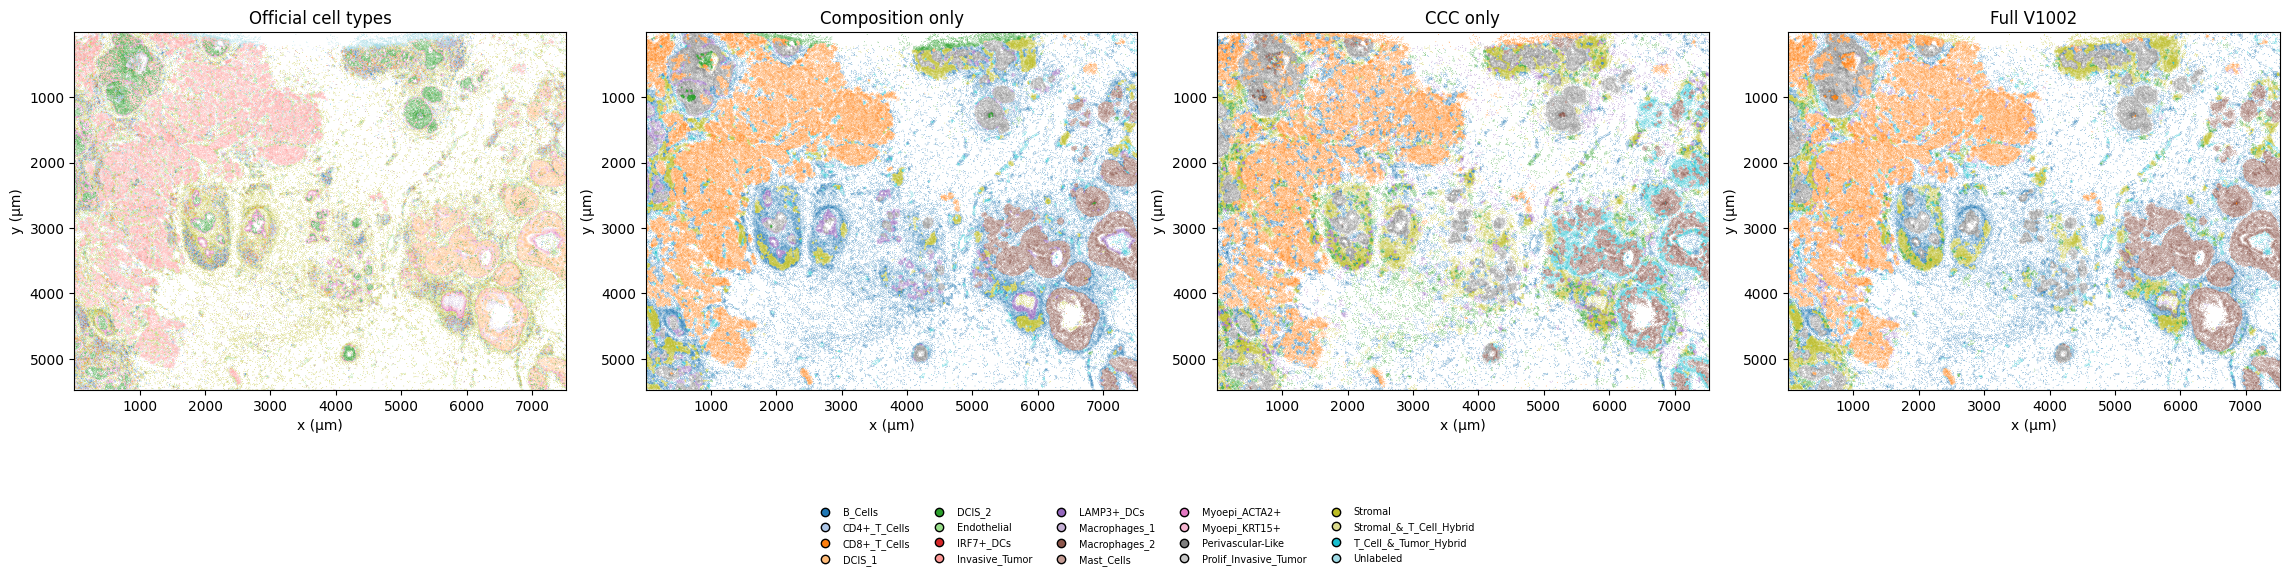

In [11]:
fig,axes=plt.subplots(1,4,figsize=(23,5.5))
spatial_panels=[('Official cell types',type_colors[cell_type]),
                ('Composition only',niche_colors[composition_niche]),
                ('CCC only',niche_colors[ccc_niche]),
                ('Full V1002',niche_colors[niche])]
xlim=(coordinates[:,0].min(),coordinates[:,0].max())
ylim=(coordinates[:,1].max(),coordinates[:,1].min())
for ax,(title,colors) in zip(axes,spatial_panels):
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(title=title,xlabel='x (µm)',ylabel='y (µm)')
    ax.set_xlim(*xlim);ax.set_ylim(*ylim);ax.set_aspect('equal')
fig.legend(handles=handles,loc='lower center',bbox_to_anchor=(.5,-.12),ncol=5,frameon=False,fontsize=7)
plt.tight_layout(rect=(0,.08,1,1));plt.show()


## 小型整体诊断与 Full niche × 官方 cell type 富集
NMI 仅是与官方 cell type 的描述性相关性，数值较高不自动表示 niche 更好。

In [12]:
edge_mask=members!=np.arange(N)[:,None]
def neighbor_agreement(labels):
    return float((labels[members]==labels[:,None])[edge_mask].mean())
diagnostic=[]
for method,labels in [('Composition only',composition_niche),('CCC only',ccc_niche),('Full V1002',niche)]:
    sizes=np.bincount(labels,minlength=K_NICHE)
    diagnostic.append({'Method':method,'Occupied niches':int((sizes>0).sum()),
                       'Largest niche fraction':float(sizes.max()/N),
                       'Spatial neighbor agreement':neighbor_agreement(labels),
                       'NMI with official cell type':normalized_mutual_info_score(cell_type,labels)})
display(pd.DataFrame(diagnostic).round(3))


,Method,Occupied niches,Largest niche fraction,Spatial neighbor agreement,NMI with official cell type
0,Composition only,8,0.307,0.817,0.472
1,CCC only,8,0.246,0.723,0.296
2,Full V1002,8,0.274,0.808,0.404


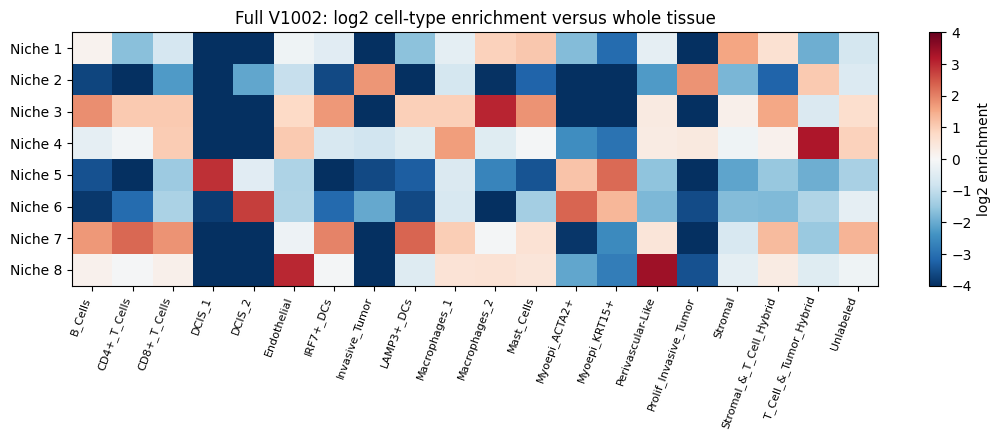

In [13]:
full_by_type=np.bincount(niche*T+cell_type,minlength=K_NICHE*T).reshape(K_NICHE,T)
within=full_by_type/np.maximum(full_by_type.sum(1,keepdims=True),1)
tissue=np.bincount(cell_type,minlength=T)/N
log2_enrichment=np.log2(within/np.maximum(tissue[None,:],1e-12)+1e-6)
fig,ax=plt.subplots(figsize=(max(10,T*.55),4.5))
image=ax.imshow(log2_enrichment,aspect='auto',cmap='RdBu_r',vmin=-4,vmax=4)
ax.set_xticks(np.arange(T),label_categories,rotation=70,ha='right',fontsize=8)
ax.set_yticks(np.arange(K_NICHE),[f'Niche {k+1}' for k in range(K_NICHE)])
ax.set_title('Full V1002: log2 cell-type enrichment versus whole tissue')
fig.colorbar(image,ax=ax,label='log2 enrichment');plt.tight_layout();plt.show()


## 组成定义区域内，Full 是否进一步拆分通讯状态

In [14]:
def conditional_centroids(base_labels):
    """One pass over I, accumulating only 8×8 group centroids; no cell-pair matrix."""
    groups=base_labels.astype(np.int64)*K_NICHE+niche
    n_groups=K_NICHE*K_NICHE
    counts=np.bincount(groups,minlength=n_groups).reshape(K_NICHE,K_NICHE)
    c_sum=np.zeros((n_groups,C.shape[1]),dtype=np.float64)
    i_sum=np.zeros((n_groups,I.shape[1]),dtype=np.float64)
    support_sum=np.zeros((n_groups,T*T),dtype=np.float64)
    for start in range(0,N,1024):
        stop=min(start+1024,N)
        indicator=sparse.csr_matrix((np.ones(stop-start,dtype=np.float32),
                                     (groups[start:stop],np.arange(stop-start))),
                                    shape=(n_groups,stop-start))
        c_sum+=indicator@C[start:stop]
        block=indicator@I[start:stop]
        i_sum+=block.toarray() if sparse.issparse(block) else np.asarray(block)
        support_sum+=indicator@(opportunity[start:stop]>0).astype(np.float32)
    divisor=np.maximum(counts.reshape(-1,1),1)
    return counts,(c_sum/divisor).reshape(K_NICHE,K_NICHE,-1),(i_sum/divisor).reshape(K_NICHE,K_NICHE,-1),(support_sum/divisor).reshape(K_NICHE,K_NICHE,T*T)

EDGE_SUPPORT_FRAC=0.10
feature_pair_index=np.flatnonzero(feature_mask)//len(measurable)

def ccc_cosine(a,b,eligible):
    # fit_balanced uses a single ST-derived RMS for the entire HI block.
    scale=fit.audit['RMS']['HI']
    a,b=a[eligible]/scale,b[eligible]/scale
    if not len(a):return float('nan')
    na,nb=np.linalg.norm(a),np.linalg.norm(b)
    if na==0 and nb==0:return 0.0
    if na==0 or nb==0:return 1.0
    return float(np.clip(1-np.dot(a,b)/(na*nb),0,2))

def refinement_pairs(base_labels,view):
    counts,c_cent,i_cent,support_frac=conditional_centroids(base_labels)
    records=[]
    for cluster in range(K_NICHE):
        total=counts[cluster].sum()
        if not total:continue
        major=np.flatnonzero((counts[cluster]>=500)&(counts[cluster]/total>=.05))
        for a,b in combinations(major,2):
            support_a,support_b=support_frac[cluster,a],support_frac[cluster,b]
            eligible_pairs=(support_a>=EDGE_SUPPORT_FRAC)&(support_b>=EDGE_SUPPORT_FRAC)
            eligible=eligible_pairs[feature_pair_index]
            records.append({'Cluster':cluster,'A_id':int(a),'B_id':int(b),
                            'eligible CCC features':int(eligible.sum()),
                            'support fraction A':float(support_a[eligible_pairs].mean()) if eligible_pairs.any() else 0.0,
                            'support fraction B':float(support_b[eligible_pairs].mean()) if eligible_pairs.any() else 0.0,
                            'n_A':int(counts[cluster,a]),'n_B':int(counts[cluster,b]),
                            'Composition JS distance':float(jensenshannon(c_cent[cluster,a],c_cent[cluster,b],base=2)),
                            'CCC cosine distance':ccc_cosine(i_cent[cluster,a],i_cent[cluster,b],eligible)})
    table=pd.DataFrame.from_records(records)
    if len(table):
        if view=='composition':
            table['priority']=table['Composition JS distance'].rank(ascending=True,method='min')+table['CCC cosine distance'].rank(ascending=False,method='min')
            table=table.sort_values(['priority','Composition JS distance','CCC cosine distance'],ascending=[True,True,False])
        else:
            table['priority']=table['CCC cosine distance'].rank(ascending=True,method='min')+table['Composition JS distance'].rank(ascending=False,method='min')
            table=table.sort_values(['priority','CCC cosine distance','Composition JS distance'],ascending=[True,True,False])
    return table,counts,i_cent,support_frac

composition_pairs,composition_counts,composition_i_cent,composition_support=refinement_pairs(composition_niche,'composition')
def show_pairs(table,cluster_title):
    columns=['Cluster','A_id','B_id','n_A','n_B','eligible CCC features','support fraction A','support fraction B','Composition JS distance','CCC cosine distance']
    shown=table.head(5).reindex(columns=columns).copy()
    shown=shown.rename(columns={'Cluster':cluster_title,'A_id':'Full niche A','B_id':'Full niche B'})
    if len(shown):
        shown['Full niche A']=shown['Full niche A'].map(lambda k:f'Niche {k+1}')
        shown['Full niche B']=shown['Full niche B'].map(lambda k:f'Niche {k+1}')
        shown[cluster_title]=shown[cluster_title].map(lambda k:f'Cluster {k+1}')
    display(shown.round(3))
show_pairs(composition_pairs,'Composition cluster')


,Composition cluster,Full niche A,Full niche B,n_A,n_B,eligible CCC features,support fraction A,support fraction B,Composition JS distance,CCC cosine distance
9,Cluster 7,Niche 3,Niche 7,1719,16605,1559,0.499,0.404,0.168,0.228
7,Cluster 4,Niche 1,Niche 6,658,5162,772,0.343,0.399,0.293,0.389
2,Cluster 1,Niche 3,Niche 7,3675,6482,1411,0.548,0.510,0.155,0.192
13,Cluster 8,Niche 3,Niche 7,704,960,1452,0.522,0.510,0.187,0.221
14,Cluster 8,Niche 3,Niche 8,704,3566,1153,0.640,0.379,0.222,0.228


## 一个 composition-defined region 的空间例子与 directed CCC 差异

/tmp/ipykernel_1781167/2472051335.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter(coordinates[region,0],coordinates[region,1],c=niche_colors[cluster],s=.28,linewidths=0,rasterized=True)


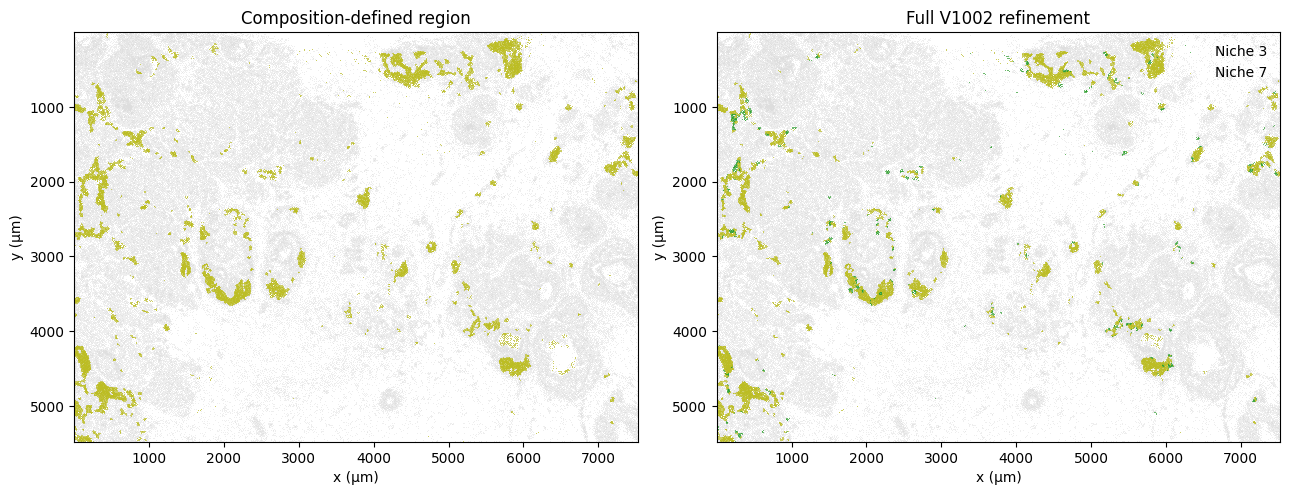

,Direction,Directed CCC,mean A,mean B,support fraction A,support fraction B,log2(A/B)
0,Niche 3 > Niche 7,Unlabeled → Macrophages_2 | CDH1–CDH1,0.057,0.001,0.809,0.145,6.238
1,Niche 3 > Niche 7,Macrophages_2 → Unlabeled | CDH1–CDH1,0.057,0.001,0.809,0.145,6.238
2,Niche 3 > Niche 7,Macrophages_2 → Macrophages_1 | CDH1–CDH1,0.021,0.001,0.943,0.172,5.347
3,Niche 3 > Niche 7,Macrophages_1 → Macrophages_2 | CDH1–CDH1,0.021,0.001,0.943,0.172,5.347
4,Niche 3 > Niche 7,Macrophages_2 → Unlabeled | MMP2–PECAM1,0.145,0.005,0.809,0.145,4.755
5,Niche 3 > Niche 7,Unlabeled → Macrophages_2 | PECAM1–PECAM1,0.276,0.013,0.809,0.145,4.391
6,Niche 3 > Niche 7,Macrophages_2 → Unlabeled | PECAM1–PECAM1,0.276,0.013,0.809,0.145,4.391
7,Niche 3 > Niche 7,B_Cells → Macrophages_2 | CEACAM6–CEACAM6,0.093,0.005,0.913,0.160,4.190
8,Niche 3 > Niche 7,Macrophages_2 → B_Cells | CEACAM6–CEACAM6,0.093,0.005,0.913,0.160,4.190
9,Niche 3 > Niche 7,Macrophages_2 → Macrophages_1 | CCL5–SDC4,0.016,0.001,0.943,0.172,4.118


In [15]:
if composition_pairs.empty:
    display(Markdown('没有同时满足 ≥5% 和 ≥500 cells 的 Full niche pair；空间例子与 CCC 差异表不适用。'))
else:
    chosen=composition_pairs.iloc[0]
    cluster,a,b=map(int,[chosen['Cluster'],chosen['A_id'],chosen['B_id']])
    region=composition_niche==cluster
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    for ax in axes:
        ax.scatter(coordinates[:,0],coordinates[:,1],c='#dddddd',s=.18,linewidths=0,rasterized=True)
        ax.set_xlim(*xlim);ax.set_ylim(*ylim);ax.set_aspect('equal')
        ax.set(xlabel='x (µm)',ylabel='y (µm)')
    axes[0].scatter(coordinates[region,0],coordinates[region,1],c=niche_colors[cluster],s=.28,linewidths=0,rasterized=True)
    axes[0].set_title('Composition-defined region')
    for k in (a,b):
        selected=region&(niche==k)
        axes[1].scatter(coordinates[selected,0],coordinates[selected,1],c=[niche_colors[k]],s=.28,linewidths=0,rasterized=True,label=f'Niche {k+1}')
    axes[1].set_title('Full V1002 refinement');axes[1].legend(frameon=False)
    plt.tight_layout();plt.show()

    mean_a=composition_i_cent[cluster,a];mean_b=composition_i_cent[cluster,b]
    support_a=composition_support[cluster,a]
    support_b=composition_support[cluster,b]
    eligible_pairs=(support_a>=EDGE_SUPPORT_FRAC)&(support_b>=EDGE_SUPPORT_FRAC)
    eligible_features=eligible_pairs[feature_pair_index]
    log_ratio=np.log2((mean_a+1e-6)/(mean_b+1e-6))
    selected_indices=np.flatnonzero(feature_mask)
    assert len(selected_indices)==I.shape[1]
    feature_names=[]
    n_lr=len(measurable)
    for index in selected_indices:
        pair,lr=divmod(int(index),n_lr)
        sender,receiver=divmod(pair,T)
        interaction=measurable[lr]
        feature_names.append(f'{label_categories[sender]} → {label_categories[receiver]} | {interaction.ligand}–{interaction.receptor}')
    a_higher=np.flatnonzero(eligible_features&(log_ratio>0))[np.argsort(-log_ratio[eligible_features&(log_ratio>0)])[:10]]
    b_higher=np.flatnonzero(eligible_features&(log_ratio<0))[np.argsort(log_ratio[eligible_features&(log_ratio<0)])[:10]]
    top=np.r_[a_higher,b_higher]
    comparison=pd.DataFrame({'Direction':[f'Niche {a+1} > Niche {b+1}']*len(a_higher)+[f'Niche {b+1} > Niche {a+1}']*len(b_higher),
                             'Directed CCC':[feature_names[j] for j in top],
                             'mean A':mean_a[top],'mean B':mean_b[top],
                             'support fraction A':support_a[feature_pair_index[top]],
                             'support fraction B':support_b[feature_pair_index[top]],
                             'log2(A/B)':log_ratio[top]})
    display(comparison.round(3))


## CCC 定义区域内，Full 是否进一步拆分组成状态

In [16]:
ccc_pairs,ccc_counts,ccc_i_cent,ccc_support=refinement_pairs(ccc_niche,'ccc')
show_pairs(ccc_pairs,'CCC cluster')


,CCC cluster,Full niche A,Full niche B,n_A,n_B,eligible CCC features,support fraction A,support fraction B,Composition JS distance,CCC cosine distance
13,Cluster 8,Niche 1,Niche 5,1805,8119,833,0.501,0.365,0.519,0.068
2,Cluster 1,Niche 2,Niche 8,6044,4953,724,0.391,0.423,0.588,0.120
0,Cluster 1,Niche 1,Niche 2,12305,6044,619,0.322,0.416,0.671,0.156
8,Cluster 5,Niche 5,Niche 6,13358,1048,459,0.323,0.375,0.683,0.183
12,Cluster 7,Niche 1,Niche 7,8521,19076,1036,0.396,0.540,0.422,0.054


## 简短汇总（仅描述，不自动作科学结论）

In [17]:
def best_summary(table):
    if table.empty:return 'None','NA','NA'
    row=table.iloc[0]
    return (f"Niche {int(row['A_id'])+1} / Niche {int(row['B_id'])+1}",
            f"{row['Composition JS distance']:.3f}",f"{row['CCC cosine distance']:.3f}")
comp_pair,comp_js,comp_ccc=best_summary(composition_pairs)
ccc_pair,ccc_js,ccc_dist=best_summary(ccc_pairs)
print(f"Full niche count: {np.unique(niche).size}")
print(f"Composition-only vs Full ARI: {adjusted_rand_score(composition_niche,niche):.3f}")
print(f"CCC-only vs Full ARI: {adjusted_rand_score(ccc_niche,niche):.3f}")
print(f"Best composition-similar Full pair: {comp_pair}")
print(f"Composition JS: {comp_js}")
print(f"CCC distance: {comp_ccc}")
print(f"Best CCC-similar Full pair: {ccc_pair}")
print(f"Composition JS: {ccc_js}")
print(f"CCC distance: {ccc_dist}")


Full niche count: 8
Composition-only vs Full ARI: 0.678
CCC-only vs Full ARI: 0.469
Best composition-similar Full pair: Niche 3 / Niche 7
Composition JS: 0.168
CCC distance: 0.228
Best CCC-similar Full pair: Niche 1 / Niche 5
Composition JS: 0.519
CCC distance: 0.068
